# Day 18 — Underwater Garbage Detection
## YOLO11n Architecture Comparison

**Objective:** Train YOLO11n on the same TrashCAN YOLO Dataset V1 and compare it with the previously built YOLOv8n experiments.

### Methods covered
1. Day 15 — YOLOv8n baseline, 640 × 640
2. Day 16 — YOLOv8n, 832 × 832
3. Day 17 — tuned YOLOv8n
4. Day 18 — YOLO11n, 640 × 640

### Metrics
- mAP50
- mAP50-95
- Precision
- Recall
- F1-score
- Class-wise performance
- Inference time
- Software FPS

**Important:** Day 15–17 runs are read from their saved `results.csv` / checkpoints. They are not retrained in this notebook.

In [1]:
# ============================================================
# 1. SETUP
# ============================================================

!pip install -q ultralytics

import os
import time
import json
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 760.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 5.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Setup complete.


In [2]:
# ============================================================
# RESTORE THE EXACT DATASET V1 USED BY DAY 15/16/17
# ============================================================

from pathlib import Path
import os
import json
import yaml
import zipfile
import shutil
import hashlib
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")

V1_ROOT = Path("/content/TrashCAN_YOLO_Dataset_V1")
DATA_YAML = V1_ROOT / "data.yaml"

SOURCE_ZIP = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip"
)

SOURCE_ROOT = Path("/content/TrashCAN")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("PROJECT_DIR :", PROJECT_DIR)
print("SOURCE_ZIP  :", SOURCE_ZIP)
print("V1_ROOT     :", V1_ROOT)
print("DATA_YAML   :", DATA_YAML)

# ------------------------------------------------------------
# If Dataset V1 already exists, don't recreate it
# ------------------------------------------------------------

if DATA_YAML.exists():

    print("\n✅ Dataset V1 already exists.")
    print("Using:", DATA_YAML)

else:

    print("\n⚠️ Dataset V1 is missing.")
    print("Rebuilding it from the original Day 16 source dataset...")

    if not SOURCE_ZIP.exists():
        raise FileNotFoundError(
            f"Source dataset ZIP not found:\n{SOURCE_ZIP}"
        )

    # --------------------------------------------------------
    # Extract original dataset
    # --------------------------------------------------------

    if not SOURCE_ROOT.exists():

        print("\nExtracting source dataset...")

        SOURCE_ROOT.mkdir(
            parents=True,
            exist_ok=True
        )

        with zipfile.ZipFile(
            SOURCE_ZIP,
            "r"
        ) as z:

            z.extractall(SOURCE_ROOT)

        print("✅ Source dataset extracted.")

    else:

        print("\n✅ Source dataset folder already exists.")

    # --------------------------------------------------------
    # Locate material_version
    # --------------------------------------------------------

    dataset_path = SOURCE_ROOT / "dataset"

    material_path = (
        dataset_path / "material_version"
    )

    if not material_path.exists():

        matches = list(
            SOURCE_ROOT.rglob("material_version")
        )

        if matches:
            material_path = matches[0]

    if not material_path.exists():

        raise FileNotFoundError(
            "material_version was not found inside:\n"
            f"{SOURCE_ROOT}"
        )

    print("\nMaterial-version:")
    print(material_path)

    # --------------------------------------------------------
    # Source train / validation
    # --------------------------------------------------------

    train_path = material_path / "train"
    val_path = material_path / "val"

    train_json_path = (
        material_path /
        "instances_train_trashcan.json"
    )

    val_json_path = (
        material_path /
        "instances_val_trashcan.json"
    )

    required = [
        (train_path, "material_version/train"),
        (val_path, "material_version/val"),
        (train_json_path, "training COCO JSON"),
        (val_json_path, "validation COCO JSON"),
    ]

    for p, label in required:

        if not p.exists():

            raise FileNotFoundError(
                f"{label} not found:\n{p}"
            )

    # --------------------------------------------------------
    # Load COCO annotations
    # --------------------------------------------------------

    with open(
        train_json_path,
        "r",
        encoding="utf-8"
    ) as f:

        train_data = json.load(f)

    with open(
        val_json_path,
        "r",
        encoding="utf-8"
    ) as f:

        val_data = json.load(f)

    categories = train_data["categories"]

    category_names = {
        c["id"]: c["name"]
        for c in categories
    }

    # EXACT 8 garbage classes used in Dataset V1
    garbage_classes = {
        "trash_etc",
        "trash_fabric",
        "trash_fishing_gear",
        "trash_metal",
        "trash_paper",
        "trash_plastic",
        "trash_rubber",
        "trash_wood",
    }

    garbage_ids = {
        c["id"]
        for c in categories
        if c["name"] in garbage_classes
    }

    # --------------------------------------------------------
    # Build image records
    # --------------------------------------------------------

    image_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    )

    def list_images(folder):

        return sorted(
            f
            for f in os.listdir(folder)
            if f.lower().endswith(image_extensions)
        )

    train_images = list_images(train_path)
    val_images = list_images(val_path)

    print("\n===== SOURCE DATASET =====")
    print("Train images :", len(train_images))
    print("Val images   :", len(val_images))

    # --------------------------------------------------------
    # Annotation lookup
    # --------------------------------------------------------

    annotation_lookup = defaultdict(list)

    for ann in train_data["annotations"]:

        annotation_lookup[
            ("train", ann["image_id"])
        ].append(ann)

    for ann in val_data["annotations"]:

        annotation_lookup[
            ("val", ann["image_id"])
        ].append(ann)

    image_records = []

    for source_pool, data, image_folder in [
        ("train", train_data, train_path),
        ("val", val_data, val_path),
    ]:

        for img in data["images"]:

            filename = img["file_name"]

            image_path = image_folder / filename

            if not image_path.exists():
                continue

            # SHA-256 exact-content grouping
            sha256 = hashlib.sha256()

            with open(image_path, "rb") as f:

                for chunk in iter(
                    lambda: f.read(1024 * 1024),
                    b""
                ):

                    sha256.update(chunk)

            image_records.append({
                "source_pool": source_pool,
                "image_id": int(img["id"]),
                "filename": filename,
                "image_path": str(image_path),
                "width": int(img["width"]),
                "height": int(img["height"]),
                "sha256": sha256.hexdigest(),
            })

    records_df = pd.DataFrame(image_records)

    print(
        "\nTotal indexed images:",
        len(records_df)
    )

    # --------------------------------------------------------
    # EXACT DAY 16 GROUP-AWARE SPLIT
    # --------------------------------------------------------

    from sklearn.model_selection import GroupShuffleSplit

    # 10% test
    gss_test = GroupShuffleSplit(
        n_splits=1,
        test_size=0.10,
        random_state=RANDOM_SEED
    )

    trainval_idx, test_idx = next(
        gss_test.split(
            records_df,
            groups=records_df["sha256"]
        )
    )

    trainval_df = records_df.iloc[
        trainval_idx
    ].copy()

    test_df = records_df.iloc[
        test_idx
    ].copy()

    # approximately 10% validation
    gss_val = GroupShuffleSplit(
        n_splits=1,
        test_size=1 / 9,
        random_state=RANDOM_SEED
    )

    train_idx, val_idx = next(
        gss_val.split(
            trainval_df,
            groups=trainval_df["sha256"]
        )
    )

    train_df = trainval_df.iloc[
        train_idx
    ].copy()

    val_df = trainval_df.iloc[
        val_idx
    ].copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    split_df = pd.concat(
        [
            train_df,
            val_df,
            test_df
        ],
        ignore_index=True
    )

    # Check exact duplicate leakage
    hash_split_counts = (
        split_df
        .groupby("sha256")["split"]
        .nunique()
    )

    cross_split_hashes = (
        hash_split_counts[
            hash_split_counts > 1
        ]
    )

    print("\n===== FINAL SPLIT =====")
    print(
        split_df["split"].value_counts()
    )

    print("\nPercentages:")
    print(
        (
            split_df["split"]
            .value_counts(normalize=True)
            * 100
        ).round(2)
    )

    print(
        "\nExact duplicate hashes crossing splits:",
        len(cross_split_hashes)
    )

    assert len(cross_split_hashes) == 0

    # --------------------------------------------------------
    # YOLO class mapping
    # --------------------------------------------------------

    yolo_names = sorted(
        garbage_classes
    )

    yolo_class_map = {
        category_id: yolo_names.index(
            category_names[category_id]
        )
        for category_id in garbage_ids
    }

    print("\nYOLO classes:")

    for i, name in enumerate(yolo_names):
        print(i, "->", name)

    # --------------------------------------------------------
    # COCO -> YOLO conversion
    # --------------------------------------------------------

    def coco_bbox_to_yolo(
        bbox,
        image_width,
        image_height
    ):

        x, y, w, h = bbox

        x1 = max(0, x)
        y1 = max(0, y)

        x2 = min(
            image_width,
            x + w
        )

        y2 = min(
            image_height,
            y + h
        )

        clipped_w = x2 - x1
        clipped_h = y2 - y1

        if clipped_w <= 0 or clipped_h <= 0:
            return None

        x_center = (
            x1 + x2
        ) / 2.0 / image_width

        y_center = (
            y1 + y2
        ) / 2.0 / image_height

        norm_w = (
            clipped_w / image_width
        )

        norm_h = (
            clipped_h / image_height
        )

        values = [
            x_center,
            y_center,
            norm_w,
            norm_h
        ]

        return [
            min(1.0, max(0.0, v))
            for v in values
        ]

    # --------------------------------------------------------
    # CREATE DATASET V1
    # --------------------------------------------------------

    if V1_ROOT.exists():

        print("\nRemoving incomplete Dataset V1...")

        shutil.rmtree(V1_ROOT)

    for split_name in [
        "train",
        "val",
        "test"
    ]:

        (
            V1_ROOT /
            "images" /
            split_name
        ).mkdir(
            parents=True,
            exist_ok=True
        )

        (
            V1_ROOT /
            "labels" /
            split_name
        ).mkdir(
            parents=True,
            exist_ok=True
        )

    from shutil import copy2
    from tqdm.auto import tqdm

    print("\nCreating Dataset V1...")

    for _, row in tqdm(
        split_df.iterrows(),
        total=len(split_df),
        desc="Creating Dataset V1"
    ):

        split_name = row["split"]
        source_pool = row["source_pool"]

        image_id = int(
            row["image_id"]
        )

        filename = row["filename"]

        destination_image = (
            V1_ROOT /
            "images" /
            split_name /
            filename
        )

        destination_label = (
            V1_ROOT /
            "labels" /
            split_name /
            f"{Path(filename).stem}.txt"
        )

        copy2(
            row["image_path"],
            destination_image
        )

        yolo_lines = []

        for ann in annotation_lookup[
            (source_pool, image_id)
        ]:

            cid = int(
                ann["category_id"]
            )

            # Garbage classes only
            if cid not in yolo_class_map:
                continue

            box = coco_bbox_to_yolo(
                ann["bbox"],
                int(row["width"]),
                int(row["height"])
            )

            if box is None:
                continue

            yolo_lines.append(
                str(
                    yolo_class_map[cid]
                )
                + " "
                + " ".join(
                    f"{v:.6f}"
                    for v in box
                )
            )

        destination_label.write_text(
            "\n".join(yolo_lines),
            encoding="utf-8"
        )

    # --------------------------------------------------------
    # Save data.yaml
    # --------------------------------------------------------

    data_yaml = {
        "path": str(V1_ROOT),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": [
            yolo_names[i]
            for i in range(len(yolo_names))
        ]
    }

    with open(
        DATA_YAML,
        "w",
        encoding="utf-8"
    ) as f:

        yaml.safe_dump(
            data_yaml,
            f,
            sort_keys=False,
            allow_unicode=True
        )

    # Save split manifest
    split_path = (
        V1_ROOT /
        "split_manifest.csv"
    )

    split_df.sort_values(
        ["split", "filename"]
    ).to_csv(
        split_path,
        index=False
    )

    print("\n✅ Dataset V1 created.")

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print("\n========================================")
print("DATASET V1 VERIFICATION")
print("========================================")

print("DATA_YAML:", DATA_YAML)
print("Exists   :", DATA_YAML.exists())

assert DATA_YAML.exists()

for split in [
    "train",
    "val",
    "test"
]:

    image_dir = (
        V1_ROOT /
        "images" /
        split
    )

    label_dir = (
        V1_ROOT /
        "labels" /
        split
    )

    image_count = len([
        p for p in image_dir.iterdir()
        if p.suffix.lower()
        in image_extensions
    ])

    label_count = len(
        list(label_dir.glob("*.txt"))
    )

    print(
        f"{split:5s} -> "
        f"images={image_count}, "
        f"labels={label_count}"
    )

    assert image_count == label_count

print("\n✅ DATASET V1 READY")
print("You can now continue with Day 18.")

Mounted at /content/drive
PROJECT_DIR : /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs
SOURCE_ZIP  : /content/drive/MyDrive/INTERNSHIPWORK/dataset.zip
V1_ROOT     : /content/TrashCAN_YOLO_Dataset_V1
DATA_YAML   : /content/TrashCAN_YOLO_Dataset_V1/data.yaml

⚠️ Dataset V1 is missing.
Rebuilding it from the original Day 16 source dataset...

Extracting source dataset...
✅ Source dataset extracted.

Material-version:
/content/TrashCAN/dataset/material_version

===== SOURCE DATASET =====
Train images : 6008
Val images   : 1204

Total indexed images: 7212

===== FINAL SPLIT =====
split
train    5768
val       722
test      722
Name: count, dtype: int64

Percentages:
split
train    79.98
val      10.01
test     10.01
Name: proportion, dtype: float64

Exact duplicate hashes crossing splits: 0

YOLO classes:
0 -> trash_etc
1 -> trash_fabric
2 -> trash_fishing_gear
3 -> trash_metal
4 -> trash_paper
5 -> trash_plastic
6 -> trash_rubber
7 -> trash_wood

Creating Dataset V1...


Creating Dataset V1:   0%|          | 0/7212 [00:00<?, ?it/s]


✅ Dataset V1 created.

DATASET V1 VERIFICATION
DATA_YAML: /content/TrashCAN_YOLO_Dataset_V1/data.yaml
Exists   : True
train -> images=5768, labels=5768
val   -> images=722, labels=722
test  -> images=722, labels=722

✅ DATASET V1 READY
You can now continue with Day 18.


## 3. Dataset and experiment consistency

Day 18 uses the existing **TrashCAN YOLO Dataset V1** and its existing train/validation/test split.

For the architecture comparison, YOLO11n is trained at **640 × 640**, matching the Day 15 YOLOv8n baseline image size.

This avoids changing both architecture and image size at the same time for the main Day 15 vs Day 18 comparison.

In [3]:
# ============================================================
# 3. CHECK DATASET YAML
# ============================================================

print(DATA_YAML.read_text()[:5000])

path: /content/TrashCAN_YOLO_Dataset_V1
train: images/train
val: images/val
test: images/test
names:
- trash_etc
- trash_fabric
- trash_fishing_gear
- trash_metal
- trash_paper
- trash_plastic
- trash_rubber
- trash_wood



In [4]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
from ultralytics import YOLO

PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")
DATASET_ROOT = Path("/content/TrashCAN_YOLO_Dataset_V1")
DATA_YAML = DATASET_ROOT / "data.yaml"

DAY18_RUN_NAME = "day18_yolo11n_640-4"
DAY18_RUN_DIR = PROJECT_DIR / DAY18_RUN_NAME
DAY18_LAST = DAY18_RUN_DIR / "weights" / "last.pt"
DAY18_BEST = DAY18_RUN_DIR / "weights" / "best.pt"
DAY18_CSV = DAY18_RUN_DIR / "results.csv"

print("PROJECT_DIR :", PROJECT_DIR)
print("DATA_YAML   :", DATA_YAML)
print("RUN DIR     :", DAY18_RUN_DIR)
print("last.pt     :", DAY18_LAST.exists())
print("best.pt     :", DAY18_BEST.exists())
print("results.csv :", DAY18_CSV.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR : /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs
DATA_YAML   : /content/TrashCAN_YOLO_Dataset_V1/data.yaml
RUN DIR     : /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640-4
last.pt     : True
best.pt     : True
results.csv : True


In [5]:
import pandas as pd

if DAY18_CSV.exists():
    df18 = pd.read_csv(DAY18_CSV)
    df18.columns = [c.strip() for c in df18.columns]

    print("Completed/saved epochs:")
    print(df18["epoch"].tolist())

    print("\nLast saved epoch:", int(df18["epoch"].max()) + 1)
else:
    print("results.csv not found.")

Completed/saved epochs:
[1, 2, 3, 4]

Last saved epoch: 5


# 4. Train YOLO11n

This is the **only new training run** in Day 18.

The model is loaded from the pretrained `yolo11n.pt` checkpoint and trained on the same dataset.

In [6]:
# ============================================================
# 4. YOLO11n TRAINING
# ============================================================

# If Day 18 was already completed, do NOT rerun this cell.
# The following cell can load the saved best.pt instead.

# Define training parameters
DAY18_IMGSZ = 640
DAY18_EPOCHS = 50  # Using a reasonable default
DAY18_BATCH = 16   # Using a reasonable default

# Define run directories
RUNS_DIR = PROJECT_DIR # PROJECT_DIR was defined earlier
DAY18_RUN_NAME = "day18_yolo11n_640"
DAY18_RUN_DIR = RUNS_DIR / DAY18_RUN_NAME

model18 = YOLO("yolo11n.pt")

results18 = model18.train(
    data=str(DATA_YAML),
    imgsz=DAY18_IMGSZ,
    epochs=DAY18_EPOCHS,
    batch=DAY18_BATCH,

    project=str(RUNS_DIR),
    name=DAY18_RUN_NAME,

    pretrained=True,
    workers=2,
    cache=False,

    plots=True,
    save=True,
    verbose=True
)

print("\nDay 18 YOLO11n training completed.")
print("Run directory:", DAY18_RUN_DIR)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TrashCAN_YOLO_Dataset_V1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=day18_yolo11n_640-5, nbs=64, nms=None, opset=N

In [9]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is NOT connected")

PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


## 5. Load the saved YOLO11n checkpoint

Run this section after training, or use it directly if the Day 18 run already exists.

In [10]:
# ============================================================
# 5. LOAD DAY 18 BEST CHECKPOINT
# ============================================================

DAY18_BEST_PT = DAY18_RUN_DIR / "weights" / "best.pt"

if not DAY18_BEST_PT.exists():
    raise FileNotFoundError(
        f"YOLO11n best.pt not found:\n{DAY18_BEST_PT}\n"
        "Run the training cell first."
    )

model18 = YOLO(str(DAY18_BEST_PT))

print("Loaded:", DAY18_BEST_PT)
print("Classes:", model18.names)

Loaded: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640/weights/best.pt
Classes: {0: 'trash_etc', 1: 'trash_fabric', 2: 'trash_fishing_gear', 3: 'trash_metal', 4: 'trash_paper', 5: 'trash_plastic', 6: 'trash_rubber', 7: 'trash_wood'}


In [11]:
# ============================================================
# 6. DAY 18 TRAINING RESULTS
# ============================================================

DAY18_RESULTS_CSV = DAY18_RUN_DIR / "results.csv"

if not DAY18_RESULTS_CSV.exists():
    raise FileNotFoundError(f"results.csv not found:\n{DAY18_RESULTS_CSV}")

r18 = pd.read_csv(DAY18_RESULTS_CSV)
r18.columns = [str(c).strip() for c in r18.columns]

display(r18.tail())

required_cols = [
    "epoch",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

missing = [c for c in required_cols if c not in r18.columns]

if missing:
    raise KeyError(f"Missing columns in Day 18 results.csv: {missing}")

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,4302.64,1.41037,3.96993,1.3466,0.52222,0.17873,0.14074,0.07910,1.44152,3.80597,1.40103,0.000277,0.000277,0.000277
1,2,8524.65,1.47834,3.16609,1.4042,0.40757,0.20938,0.13872,0.07957,1.54457,3.53747,1.43669,0.000549,0.000549,0.000549


In [12]:
# ============================================================
# 7. BEST DAY 18 METRICS
# ============================================================

best18_row = r18.loc[
    r18["metrics/mAP50-95(B)"].idxmax()
]

p18 = float(best18_row["metrics/precision(B)"])
r18_recall = float(best18_row["metrics/recall(B)"])

f1_18 = (
    2 * p18 * r18_recall / (p18 + r18_recall)
    if (p18 + r18_recall) > 0
    else 0.0
)

day18_summary = {
    "Best Epoch": int(best18_row["epoch"]),
    "Precision": p18,
    "Recall": r18_recall,
    "mAP50": float(best18_row["metrics/mAP50(B)"]),
    "mAP50-95": float(best18_row["metrics/mAP50-95(B)"]),
    "F1": f1_18
}

day18_summary_df = pd.DataFrame([day18_summary])

display(day18_summary_df.round(5))

,Best Epoch,Precision,Recall,mAP50,mAP50-95,F1
0,2,0.40757,0.20938,0.13872,0.07957,0.27664


# 8. Training curves

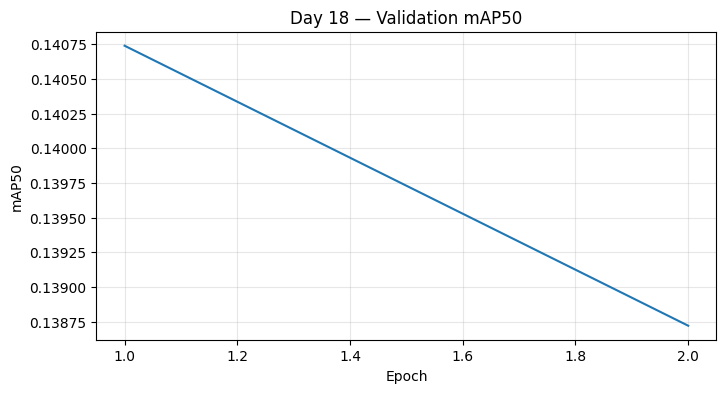

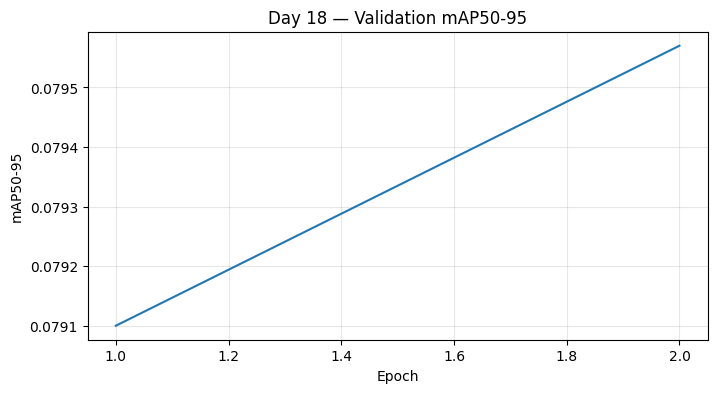

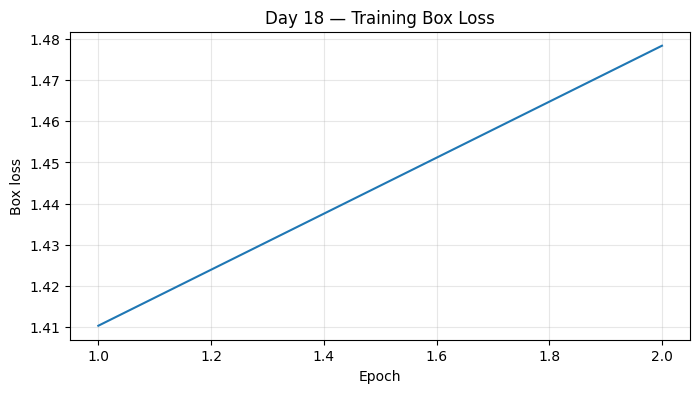

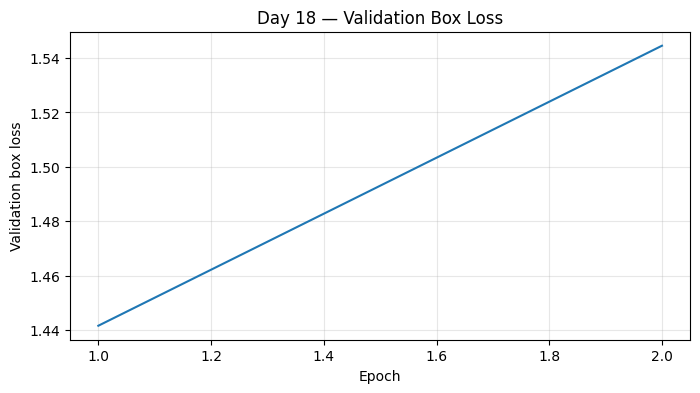

In [13]:
# ============================================================
# 8. DAY 18 TRAINING CURVES
# ============================================================

curve_specs = [
    ("metrics/mAP50(B)", "mAP50", "Day 18 — Validation mAP50"),
    ("metrics/mAP50-95(B)", "mAP50-95", "Day 18 — Validation mAP50-95"),
    ("train/box_loss", "Box loss", "Day 18 — Training Box Loss"),
    ("val/box_loss", "Validation box loss", "Day 18 — Validation Box Loss"),
]

for metric, ylabel, title in curve_specs:
    if metric in r18.columns:
        plt.figure(figsize=(8, 4))
        plt.plot(r18["epoch"], r18[metric])
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.show()

# 9. Full validation and class-wise performance

The saved best YOLO11n checkpoint is validated on the existing validation split.

The class-wise table is generated directly from Ultralytics validation metrics.

In [15]:
# ============================================================
# 9. YOLO11n VALIDATION
# ============================================================

metrics18 = model18.val(
    data=str(DATA_YAML),
    imgsz=DAY18_IMGSZ,
    plots=True,
    verbose=True
)

print("YOLO11n validation completed.")

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,583,712 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1155.8±265.1 MB/s, size: 24.6 KB)
val: Scanning /content/TrashCAN_YOLO_Dataset_V1/labels/val.cache... 722 images, 178 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 722/722 252.4Mit/s 0.0s
val: /content/TrashCAN_YOLO_Dataset_V1/images/val/vid_000532_frame0000001.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 5.8it/s 7.9s
                   all        722        653      0.408      0.208      0.139     0.0799
             trash_etc        179        211      0.194      0.299      0.145     0.0662
          trash_fabric         37         45      0.222      0.111      0.173      0.127
    trash_fishing_gear         14         15          1          0     0.0016   0.000629
          

In [17]:
# ============================================================
# 10. CLASS-WISE METRICS — YOLO11n
# ============================================================

class_results18 = []

class_names18 = model18.names

p_arr = np.asarray(metrics18.box.p).reshape(-1)
r_arr = np.asarray(metrics18.box.r).reshape(-1)
ap50_arr = np.asarray(metrics18.box.ap50).reshape(-1)
ap_arr = np.asarray(metrics18.box.ap).reshape(-1)

for class_id, class_name in class_names18.items():

    p = float(p_arr[class_id])
    rec = float(r_arr[class_id])

    f1 = (
        2 * p * rec / (p + rec)
        if (p + rec) > 0
        else 0.0
    )

    class_results18.append({
        "Class": class_name,
        "Precision": p,
        "Recall": rec,
        "F1": f1,
        "mAP50": float(ap50_arr[class_id]),
        "mAP50-95": float(ap_arr[class_id])
    })

day18_class_df = pd.DataFrame(class_results18)

display(day18_class_df.round(5))

,Class,Precision,Recall,F1,mAP50,mAP50-95
0,trash_etc,0.19350,0.29858,0.23482,0.14481,0.06618
1,trash_fabric,0.22232,0.11111,0.14817,0.17266,0.12686
2,trash_fishing_gear,1.00000,0.00000,0.00000,0.00160,0.00063
3,trash_metal,0.10572,0.41667,0.16865,0.14805,0.07734
4,trash_paper,0.11355,0.05556,0.07461,0.09447,0.06315
5,trash_plastic,0.35463,0.42857,0.38811,0.28645,0.15732
6,trash_rubber,1.00000,0.00000,0.00000,0.02787,0.00821
7,trash_wood,0.27465,0.35714,0.31051,0.23778,0.13938


# 11. Inference time and software FPS

The following timing uses the validation images and the saved YOLO11n checkpoint.

**Definition used here:** software FPS is calculated from the total `model.predict()` elapsed time over the validation images. This includes the normal prediction pipeline rather than reporting only raw GPU kernel latency.

In [18]:
# ============================================================
# 11. SOFTWARE FPS / INFERENCE TIME — YOLO11n
# ============================================================

VAL_IMAGES_DIR = DATASET_ROOT / "images" / "val"

if not VAL_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Validation image directory not found:\n{VAL_IMAGES_DIR}")

val_images = sorted([
    p for p in VAL_IMAGES_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
])

if not val_images:
    raise FileNotFoundError(f"No validation images found in:\n{VAL_IMAGES_DIR}")

print("Validation images:", len(val_images))

# Warm-up
_ = model18.predict(
    source=str(VAL_IMAGES_DIR),
    imgsz=DAY18_IMGSZ,
    save=False,
    verbose=False
)

start_time = time.perf_counter()

pred18 = model18.predict(
    source=str(VAL_IMAGES_DIR),
    imgsz=DAY18_IMGSZ,
    save=False,
    verbose=False
)

elapsed18 = time.perf_counter() - start_time

num_images18 = len(pred18)

avg_time_ms18 = (elapsed18 / num_images18) * 1000
fps18 = num_images18 / elapsed18

day18_speed = {
    "Images": num_images18,
    "Total time (s)": elapsed18,
    "Average time/image (ms)": avg_time_ms18,
    "Software FPS": fps18
}

display(pd.DataFrame([day18_speed]).round(4))

Validation images: 722


,Images,Total time (s),Average time/image (ms),Software FPS
0,722,9.1204,12.6321,79.1634


# 12. Find previously completed Day 15–17 runs

The notebook searches the Drive `yolo_runs` folder instead of assuming one exact run suffix.

A completed run must contain:
- `results.csv`
- `weights/best.pt`

This is useful because several resumed Day 16 runs exist.

In [19]:
# ============================================================
# 12. RUN DISCOVERY
# ============================================================

def find_completed_runs(pattern):
    candidates = []

    for run_dir in sorted(RUNS_DIR.glob(pattern)):
        csv_file = run_dir / "results.csv"
        best_pt = run_dir / "weights" / "best.pt"

        if csv_file.exists() and best_pt.exists():
            try:
                df = pd.read_csv(csv_file)
                df.columns = [str(c).strip() for c in df.columns]

                if "epoch" in df.columns and len(df) > 0:
                    last_epoch = int(df["epoch"].max())
                else:
                    last_epoch = -1

                candidates.append((last_epoch, run_dir, csv_file, best_pt))
            except Exception:
                pass

    # Longest completed run first
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates


def show_candidates(pattern):
    candidates = find_completed_runs(pattern)

    rows = []

    for epoch, run_dir, csv_file, best_pt in candidates:
        rows.append({
            "Run": run_dir.name,
            "Last epoch": epoch,
            "results.csv": str(csv_file),
            "best.pt": str(best_pt)
        })

    if rows:
        display(pd.DataFrame(rows))
    else:
        print("No completed runs found for:", pattern)

    return candidates


print("Day 15 candidates")
day15_candidates = show_candidates("day15_yolov8n_baseline*")

print("\nDay 16 candidates")
day16_candidates = show_candidates("day16_yolov8n_img832*")

print("\nDay 17 candidates")
day17_candidates = show_candidates("day17*")

Day 15 candidates


,Run,Last epoch,results.csv,best.pt
0,day15_yolov8n_baseline-11,100,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
1,day15_yolov8n_baseline-22,100,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
2,day15_yolov8n_baseline-5,100,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
3,day15_yolov8n_baseline-12,72,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
4,day15_yolov8n_baseline-14,67,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
5,day15_yolov8n_baseline-8,67,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
6,day15_yolov8n_baseline-6,65,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
7,day15_yolov8n_baseline-21,43,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
8,day15_yolov8n_baseline-17,38,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
9,day15_yolov8n_baseline-16,24,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...



Day 16 candidates


,Run,Last epoch,results.csv,best.pt
0,day16_yolov8n_img832-28,100,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
1,day16_yolov8n_img832-13,69,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
2,day16_yolov8n_img832-8,41,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
3,day16_yolov8n_img832-23,37,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
4,day16_yolov8n_img832-7,25,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
5,day16_yolov8n_img832-22,1,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
6,day16_yolov8n_img832-26,1,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
7,day16_yolov8n_img832-27,1,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...



Day 17 candidates


,Run,Last epoch,results.csv,best.pt
0,day17_yolov8n_tuned_continuation,97,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
1,day17_yolov8n_tuned_lr_aug-4,2,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...
2,day17_yolov8n_tuned_lr_aug-5,1,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...,/content/drive/MyDrive/INTERNSHIPWORK/yolo_run...


## 13. Select saved reference runs

The code below uses the longest completed run for each day.

For Day 16 this avoids accidentally comparing against a short interrupted/resumed run.
If your intended Day 17 run has a specific suffix, change `DAY17_RUN_DIR_OVERRIDE` below.

In [20]:
# ============================================================
# 13. SELECT REFERENCE RUNS
# ============================================================

def select_first_completed(candidates, label):
    if not candidates:
        raise FileNotFoundError(
            f"No completed {label} run with results.csv and best.pt was found."
        )
    return candidates[0]


_, DAY15_RUN_DIR, DAY15_CSV, DAY15_BEST_PT = select_first_completed(
    day15_candidates, "Day 15"
)

_, DAY16_RUN_DIR, DAY16_CSV, DAY16_BEST_PT = select_first_completed(
    day16_candidates, "Day 16"
)

# Optional manual override for Day 17.
# Leave as None to use the longest completed Day 17 run.
DAY17_RUN_DIR_OVERRIDE = None

if DAY17_RUN_DIR_OVERRIDE is None:
    _, DAY17_RUN_DIR, DAY17_CSV, DAY17_BEST_PT = select_first_completed(
        day17_candidates, "Day 17"
    )
else:
    DAY17_RUN_DIR = Path(DAY17_RUN_DIR_OVERRIDE)
    DAY17_CSV = DAY17_RUN_DIR / "results.csv"
    DAY17_BEST_PT = DAY17_RUN_DIR / "weights" / "best.pt"

for label, path in [
    ("Day 15", DAY15_RUN_DIR),
    ("Day 16", DAY16_RUN_DIR),
    ("Day 17", DAY17_RUN_DIR),
    ("Day 18", DAY18_RUN_DIR),
]:
    print(label, "->", path)

Day 15 -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-11
Day 16 -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28
Day 17 -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day17_yolov8n_tuned_continuation
Day 18 -> /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640


In [23]:
# ============================================================
# 14. READ SAVED DAY 15–17 METRICS
# ============================================================

r15 = pd.read_csv(DAY15_CSV)
r16 = pd.read_csv(DAY16_CSV)
r17 = pd.read_csv(DAY17_CSV)

for df in [r15, r16, r17]:
    df.columns = [str(c).strip() for c in df.columns]


def select_best_metric_row(df):
    return df.loc[df["metrics/mAP50-95(B)"].idxmax()]


def row_metrics_with_f1(df):
    row = select_best_metric_row(df)

    precision = float(row["metrics/precision(B)"])
    recall = float(row["metrics/recall(B)"])

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "Best Epoch": int(row["epoch"]),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "mAP50": float(row["metrics/mAP50(B)"]),
        "mAP50-95": float(row["metrics/mAP50-95(B)"])
    }


day15_best = row_metrics_with_f1(r15)
day16_best = row_metrics_with_f1(r16)
day17_best = row_metrics_with_f1(r17)
day18_best = day18_summary

comparison_df = pd.DataFrame([
    {
        "Method": "Day 15 — YOLOv8n 640",
        "Image size": 640,
        **day15_best
    },
    {
        "Method": "Day 16 — YOLOv8n 832",
        "Image size": 832,
        **day16_best
    },
    {
        "Method": "Day 17 — tuned YOLOv8n",
        "Image size": 832,
        **day17_best
    },
    {
        "Method": "Day 18 — YOLO11n 640",
        "Image size": 640,
        **day18_best
    }
])

display(comparison_df.round(5))

,Method,Image size,Best Epoch,Precision,Recall,F1,mAP50,mAP50-95
0,Day 15 — YOLOv8n 640,640,67,0.77974,0.58500,0.66848,0.61182,0.44163
1,Day 16 — YOLOv8n 832,832,82,0.78031,0.55798,0.65068,0.59674,0.42982
2,Day 17 — tuned YOLOv8n,832,86,0.77196,0.54070,0.63596,0.57704,0.39734
3,Day 18 — YOLO11n 640,640,2,0.40757,0.20938,0.27664,0.13872,0.07957


# 15. Class-wise comparison: YOLOv8n baseline vs YOLO11n

For the main architecture comparison, Day 15 YOLOv8n and Day 18 YOLO11n are evaluated at the same 640 × 640 image size.

This table reports actual measured class-wise metrics; no values are manually entered.

In [22]:
# ============================================================
# 15. CLASS-WISE DAY 15 VS DAY 18
# ============================================================

model15 = YOLO(str(DAY15_BEST_PT))

metrics15 = model15.val(
    data=str(DATA_YAML),
    imgsz=640,
    plots=False,
    verbose=True
)

p15_arr = np.asarray(metrics15.box.p).reshape(-1)
r15_arr = np.asarray(metrics15.box.r).reshape(-1)
ap50_15_arr = np.asarray(metrics15.box.ap50).reshape(-1)
ap15_arr = np.asarray(metrics15.box.ap).reshape(-1)

rows = []

for class_id, class_name in model15.names.items():

    p15v = float(p15_arr[class_id])
    r15v = float(r15_arr[class_id])
    p18v = float(p_arr[class_id])
    r18v = float(r_arr[class_id])

    f1_15 = (
        2 * p15v * r15v / (p15v + r15v)
        if (p15v + r15v) > 0 else 0.0
    )

    f1_18 = (
        2 * p18v * r18v / (p18v + r18v)
        if (p18v + r18v) > 0 else 0.0
    )

    rows.append({
        "Class": class_name,

        "YOLOv8n Precision": p15v,
        "YOLOv8n Recall": r15v,
        "YOLOv8n F1": f1_15,
        "YOLOv8n mAP50": float(ap50_15_arr[class_id]),
        "YOLOv8n mAP50-95": float(ap15_arr[class_id]),

        "YOLO11n Precision": p18v,
        "YOLO11n Recall": r18v,
        "YOLO11n F1": f1_18,
        "YOLO11n mAP50": float(ap50_arr[class_id]),
        "YOLO11n mAP50-95": float(ap_arr[class_id]),
    })

class_comparison_df = pd.DataFrame(rows)

display(class_comparison_df.round(5))

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 901.4±230.7 MB/s, size: 24.5 KB)
val: Scanning /content/TrashCAN_YOLO_Dataset_V1/labels/val.cache... 722 images, 178 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 722/722 137.6Mit/s 0.0s
val: /content/TrashCAN_YOLO_Dataset_V1/images/val/vid_000532_frame0000001.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 7.8it/s 5.9s
                   all        722        653      0.916      0.847      0.883      0.712
             trash_etc        179        211      0.905      0.811      0.878      0.655
          trash_fabric         37         45      0.928      0.956      0.972      0.837
    trash_fishing_gear         14         15      0.837      0.733      0.768      0.625
           tra

,Class,YOLOv8n Precision,YOLOv8n Recall,YOLOv8n F1,YOLOv8n mAP50,YOLOv8n mAP50-95,YOLO11n Precision,YOLO11n Recall,YOLO11n F1,YOLO11n mAP50,YOLO11n mAP50-95
0,trash_etc,0.90487,0.81149,0.85564,0.87833,0.65472,0.19350,0.29858,0.23482,0.14481,0.06618
1,trash_fabric,0.92788,0.95556,0.94152,0.97171,0.83690,0.22232,0.11111,0.14817,0.17266,0.12686
2,trash_fishing_gear,0.83727,0.73333,0.78186,0.76773,0.62486,1.00000,0.00000,0.00000,0.00160,0.00063
3,trash_metal,0.92587,0.86667,0.89529,0.89080,0.69073,0.10572,0.41667,0.16865,0.14805,0.07734
4,trash_paper,0.93779,0.83767,0.88490,0.87559,0.70698,0.11355,0.05556,0.07461,0.09447,0.06315
5,trash_plastic,0.94611,0.86815,0.90545,0.94921,0.78349,0.35463,0.42857,0.38811,0.28645,0.15732
6,trash_rubber,0.91856,0.80000,0.85519,0.80230,0.63537,1.00000,0.00000,0.00000,0.02787,0.00821
7,trash_wood,0.92654,0.90094,0.91356,0.92937,0.76320,0.27465,0.35714,0.31051,0.23778,0.13938


# 16. Inference speed comparison

To keep timing consistent, Day 15 YOLOv8n and Day 18 YOLO11n are timed on the same validation-image directory at 640 × 640.

The timing is measured separately from training.

In [24]:
# ============================================================
# 16. SPEED COMPARISON — YOLOv8n 640 vs YOLO11n 640
# ============================================================

def measure_software_fps(model, source, imgsz):
    # Warm-up
    _ = model.predict(
        source=str(source),
        imgsz=imgsz,
        save=False,
        verbose=False
    )

    start = time.perf_counter()

    predictions = model.predict(
        source=str(source),
        imgsz=imgsz,
        save=False,
        verbose=False
    )

    elapsed = time.perf_counter() - start
    n = len(predictions)

    return {
        "Images": n,
        "Total time (s)": elapsed,
        "Average time/image (ms)": (elapsed / n) * 1000,
        "Software FPS": n / elapsed
    }


speed15 = measure_software_fps(
    model15,
    VAL_IMAGES_DIR,
    640
)

speed18 = measure_software_fps(
    model18,
    VAL_IMAGES_DIR,
    640
)

speed_comparison_df = pd.DataFrame([
    {
        "Method": "Day 15 — YOLOv8n 640",
        **speed15
    },
    {
        "Method": "Day 18 — YOLO11n 640",
        **speed18
    }
])

display(speed_comparison_df.round(4))

,Method,Images,Total time (s),Average time/image (ms),Software FPS
0,Day 15 — YOLOv8n 640,722,6.7447,9.3417,107.0473
1,Day 18 — YOLO11n 640,722,9.2195,12.7694,78.3122


# 17. Complete Day 18 comparison table

This combines accuracy metrics and software-speed measurements.

**Note:** F1 is calculated from Precision and Recall using:

`F1 = 2 × Precision × Recall / (Precision + Recall)`

No ranking or winner is hard-coded; the notebook reports measured values for comparison.

In [25]:
# ============================================================
# 17. COMPLETE COMPARISON TABLE
# ============================================================

speed_lookup = {
    "Day 15 — YOLOv8n 640": speed15,
    "Day 16 — YOLOv8n 832": {
        "Average time/image (ms)": np.nan,
        "Software FPS": np.nan
    },
    "Day 17 — tuned YOLOv8n": {
        "Average time/image (ms)": np.nan,
        "Software FPS": np.nan
    },
    "Day 18 — YOLO11n 640": speed18
}

complete_comparison = comparison_df.copy()

complete_comparison["Inference time (ms)"] = (
    complete_comparison["Method"]
    .map({
        k: v.get("Average time/image (ms)", np.nan)
        for k, v in speed_lookup.items()
    })
)

complete_comparison["Software FPS"] = (
    complete_comparison["Method"]
    .map({
        k: v.get("Software FPS", np.nan)
        for k, v in speed_lookup.items()
    })
)

complete_comparison = complete_comparison[
    [
        "Method",
        "Image size",
        "mAP50",
        "mAP50-95",
        "Precision",
        "Recall",
        "F1",
        "Inference time (ms)",
        "Software FPS"
    ]
]

display(complete_comparison.round(5))

,Method,Image size,mAP50,mAP50-95,Precision,Recall,F1,Inference time (ms),Software FPS
0,Day 15 — YOLOv8n 640,640,0.61182,0.44163,0.77974,0.58500,0.66848,9.34167,107.04728
1,Day 16 — YOLOv8n 832,832,0.59674,0.42982,0.78031,0.55798,0.65068,NaN,NaN
2,Day 17 — tuned YOLOv8n,832,0.57704,0.39734,0.77196,0.54070,0.63596,NaN,NaN
3,Day 18 — YOLO11n 640,640,0.13872,0.07957,0.40757,0.20938,0.27664,12.76940,78.31219


## 18. Why Day 16/17 FPS may be blank

Day 18 requires software FPS in the comparison.

The notebook measures Day 15 and Day 18 directly because both are the main 640 × 640 architecture comparison.

If Day 16 and Day 17 need FPS in the final table too, run the optional timing cells below using their saved checkpoints. This avoids retraining them.

In [26]:
# ============================================================
# 18. OPTIONAL — DAY 16 / DAY 17 SPEED MEASUREMENT
# ============================================================

# Day 16
model16 = YOLO(str(DAY16_BEST_PT))

speed16 = measure_software_fps(
    model16,
    VAL_IMAGES_DIR,
    832
)

# Day 17
model17 = YOLO(str(DAY17_BEST_PT))

speed17 = measure_software_fps(
    model17,
    VAL_IMAGES_DIR,
    832
)

print("Day 16 speed:")
display(pd.DataFrame([speed16]).round(4))

print("Day 17 speed:")
display(pd.DataFrame([speed17]).round(4))

Day 16 speed:


,Images,Total time (s),Average time/image (ms),Software FPS
0,722,7.9655,11.0326,90.6405


Day 17 speed:


,Images,Total time (s),Average time/image (ms),Software FPS
0,722,7.8258,10.839,92.259


In [27]:
# ============================================================
# 19. FINAL TABLE WITH ALL SPEED RESULTS
# ============================================================

speed_all = {
    "Day 15 — YOLOv8n 640": speed15,
    "Day 16 — YOLOv8n 832": speed16,
    "Day 17 — tuned YOLOv8n": speed17,
    "Day 18 — YOLO11n 640": speed18
}

final_comparison = comparison_df.copy()

final_comparison["Inference time (ms)"] = final_comparison["Method"].map(
    lambda x: speed_all[x]["Average time/image (ms)"]
)

final_comparison["Software FPS"] = final_comparison["Method"].map(
    lambda x: speed_all[x]["Software FPS"]
)

final_comparison = final_comparison[
    [
        "Method",
        "Image size",
        "mAP50",
        "mAP50-95",
        "Precision",
        "Recall",
        "F1",
        "Inference time (ms)",
        "Software FPS"
    ]
]

display(final_comparison.round(5))

,Method,Image size,mAP50,mAP50-95,Precision,Recall,F1,Inference time (ms),Software FPS
0,Day 15 — YOLOv8n 640,640,0.61182,0.44163,0.77974,0.58500,0.66848,9.34167,107.04728
1,Day 16 — YOLOv8n 832,832,0.59674,0.42982,0.78031,0.55798,0.65068,11.03259,90.64053
2,Day 17 — tuned YOLOv8n,832,0.57704,0.39734,0.77196,0.54070,0.63596,10.83905,92.25904
3,Day 18 — YOLO11n 640,640,0.13872,0.07957,0.40757,0.20938,0.27664,12.76940,78.31219


# 20. Comparison charts

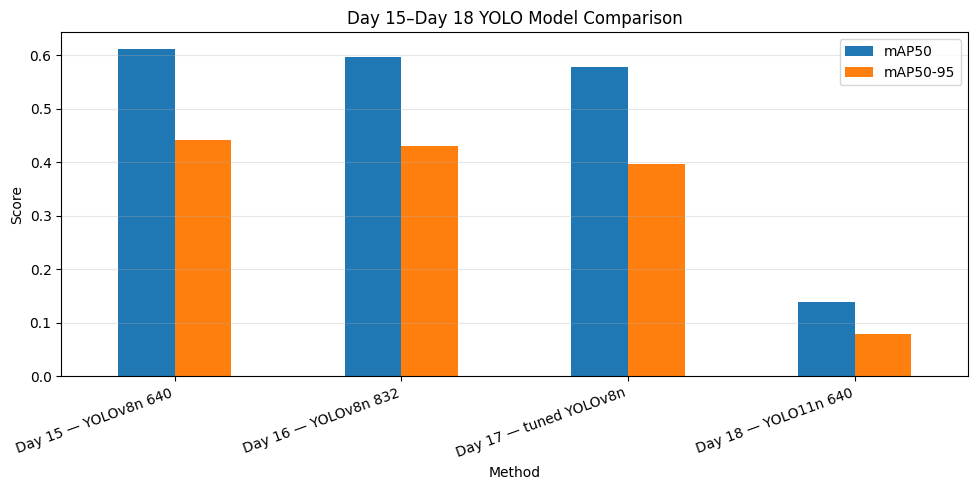

In [28]:
# ============================================================
# 20. ACCURACY COMPARISON CHART
# ============================================================

plot_df = final_comparison.set_index("Method")

plot_df[["mAP50", "mAP50-95"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.title("Day 15–Day 18 YOLO Model Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

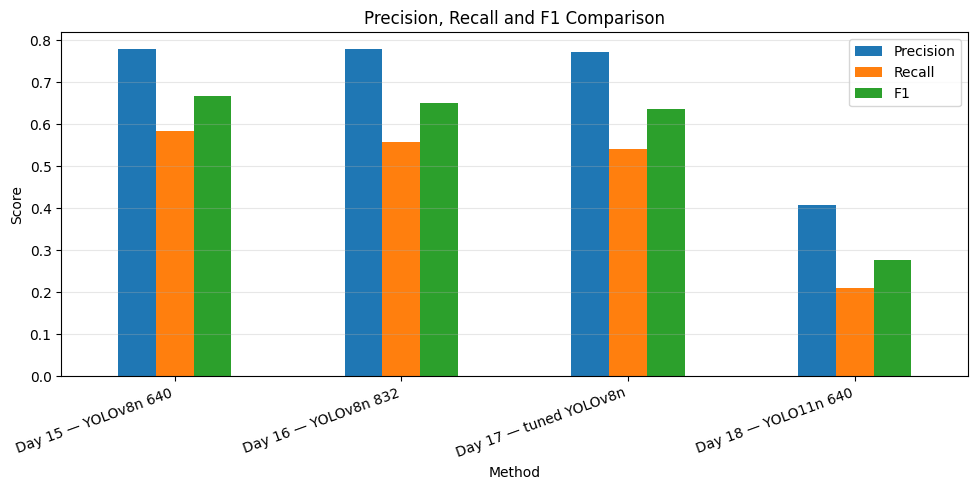

In [29]:
# ============================================================
# 21. PRECISION / RECALL / F1 COMPARISON
# ============================================================

plot_df[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Score")
plt.title("Precision, Recall and F1 Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

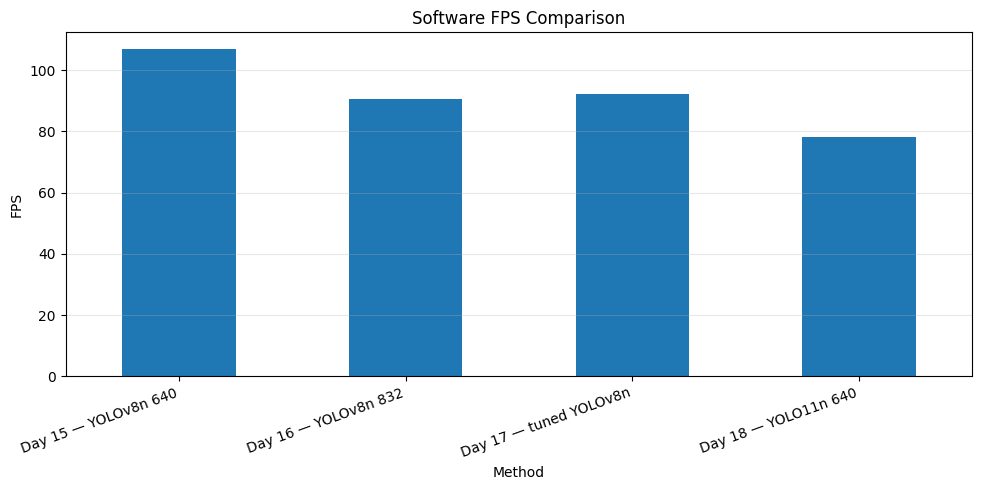

In [30]:
# ============================================================
# 22. SOFTWARE FPS COMPARISON
# ============================================================

plot_df[["Software FPS"]].plot(
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.ylabel("FPS")
plt.title("Software FPS Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 23. Day 18 observations

Use the measured table above to fill the presentation.

### Suggested factual observations
- YOLO11n was trained as a new architecture using the same dataset and split.
- The main architecture comparison with Day 15 uses 640 × 640 for both YOLOv8n and YOLO11n.
- mAP50 and mAP50-95 describe detection accuracy at different IoU criteria.
- Precision, Recall and F1 describe different aspects of detection quality.
- Class-wise metrics show which garbage categories are easier or harder to detect.
- Software FPS and inference time provide a deployment-speed view.
- The final comparison should be interpreted using the measured metrics together rather than a single number.

In [31]:
# ============================================================
# 25. SAVE DAY 18 TABLES
# ============================================================

OUTPUT_DIR = DAY18_RUN_DIR / "day18_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_comparison.to_csv(
    OUTPUT_DIR / "day18_complete_method_comparison.csv",
    index=False
)

class_comparison_df.to_csv(
    OUTPUT_DIR / "day18_yolov8n_vs_yolo11n_classwise.csv",
    index=False
)

day18_class_df.to_csv(
    OUTPUT_DIR / "day18_yolo11n_classwise.csv",
    index=False
)

with open(OUTPUT_DIR / "day18_summary.json", "w") as f:
    json.dump(
        {
            "day": 18,
            "model": "YOLO11n",
            "image_size": DAY18_IMGSZ,
            "epochs": DAY18_EPOCHS,
            "batch": DAY18_BATCH,
            "best_metrics": day18_summary,
            "software_speed": day18_speed
        },
        f,
        indent=2
    )

print("Saved Day 18 outputs to:")
print(OUTPUT_DIR)

for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)

Saved Day 18 outputs to:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day18_yolo11n_640/day18_comparison_outputs
 - day18_complete_method_comparison.csv
 - day18_summary.json
 - day18_yolo11n_classwise.csv
 - day18_yolov8n_vs_yolo11n_classwise.csv


# Day 18 — Final record

**New method:** YOLO11n  
**Reference baseline:** YOLOv8n at 640 × 640  
**Dataset:** TrashCAN YOLO Dataset V1  
**Evaluation:** mAP50, mAP50-95, Precision, Recall, F1, class-wise metrics, inference time and software FPS.

The notebook intentionally reports measured results without manually inserting or ranking values.